# Water Quality in the Reservoirs of the Guadalquivir

**Surface, chlorophyll and the month each reservoir blooms, with Sentinel-2**

A reservoir is a moving target. Its shoreline advances and retreats with the rains and
the irrigation season, and what grows in it changes with the temperature, the nutrients
the catchment sends down and how long the water stays. This notebook measures the three
things in order:

1. **Where there is water**, and how much, month by month and year by year — with the
   three water indices the library offers, compared against each other.
2. **How much chlorophyll** the water carries, using the red edge band that only
   Sentinel-2 has, and whether it is trending anywhere.
3. **When each part of the reservoir reaches its maximum**, which is what
   `get_peak_period()` was added for.

The study area is the reservoirs of the **Confederación Hidrográfica del Guadalquivir**
(CHG), the basin authority for southern Spain, from a public Earth Engine asset.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='geemap.conversion')

import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlopen
from PIL import Image
from io import BytesIO

from ndvi2gif import NdviSeasonality, TimeSeriesAnalyzer

# ee.Authenticate()          # only the first time
ee.Initialize(project='your-project-id')
print('✓ Earth Engine initialised')

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


✓ Earth Engine initialised


## 2. The reservoirs

The outlines come from a public Earth Engine asset, so the notebook runs without any
local file. Every reservoir of the basin is in there; the analysis below uses the
largest, and the last section repeats it over the top five.

In [2]:
CHG = 'projects/ee-digdgeografo/assets/CHG_CaptacionesEmbalses'

reservoirs = (ee.FeatureCollection(CHG)
              .map(lambda f: f.set('area_km2', f.geometry().area(10).divide(1e6))))

largest = reservoirs.sort('area_km2', False).limit(8)
pd.DataFrame([{'name': f['properties']['Nombre'],
               'km²': round(f['properties']['area_km2'], 1)}
              for f in largest.getInfo()['features']]).set_index('name')

,km²
name,
Iznájar,24.4
Puente Nuevo,20.2
Encinarejo,15.4
Melonares,14.6
Guadalén,14.3
Guadalmena,13.4
Bembézar,11.8
Huesna,11.3


In [3]:
NAME = 'Iznájar'          # the largest reservoir in Andalusia
YEARS = (2020, 2025)

reservoir = reservoirs.filter(ee.Filter.eq('Nombre', NAME)).first().geometry()
roi = reservoir.buffer(300)   # a margin, so the shoreline is inside the composite

print(f'{NAME}: {reservoir.area(10).divide(1e6).getInfo():.1f} km²')

Iznájar: 24.4 km²


## 3. Three ways to find water

ndvi2gif carries several water indices, and they do not agree. All three compare a band
where water is bright with one where it is dark, but they differ in which bands and in
how they handle shadows:

- **NDWI** (McFeeters 1996), green against NIR. The classic, and the one that most often
  mistakes a dark roof or a mountain shadow for water.
- **MNDWI** (Xu 2006), green against SWIR1. Water absorbs SWIR almost completely, so it
  separates water from built-up land much better.
- **AWEInsh** (Feyisa et al. 2014), a four-band combination designed to be thresholded at
  zero without tuning. The *nsh* variant is the one for areas without deep shadow.

The composites are monthly medians across six years — exactly the same call three
times, changing only `index=`.

In [4]:
def monthly(index):
    """Monthly medians of an index, one NdviSeasonality per index."""
    return NdviSeasonality(roi=roi, sat='S2', index=index, key='median', periods=12,
                           start_year=YEARS[0], end_year=YEARS[1])

water_indices = {name: monthly(name) for name in ('ndwi', 'mndwi', 'aweinsh')}
composites = {name: p.get_year_composite().median()
              for name, p in water_indices.items()}

# Area called water by each index, month by month, at the usual threshold of 0
def water_area(image, band):
    return (image.select(band).gt(0).multiply(ee.Image.pixelArea()).divide(1e6)
            .reduceRegion(ee.Reducer.sum(), roi, 20, maxPixels=1e9)
            .values().get(0).getInfo())

months = water_indices['mndwi'].period_names
area_by_index = pd.DataFrame(
    {name: [water_area(image, m) for m in months]
     for name, image in composites.items()},
    index=[m[:3].capitalize() for m in months])
area_by_index.round(2)

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering
There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering
There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2020: 12/12 periods with data using ndwi index


Year 2021: 12/12 periods with data using ndwi index


No data for period 3 (march) in year 2022, filled with a masked band
No data for period 4 (april) in year 2022, filled with a masked band
Year 2022: 10/12 periods with data using ndwi index


Year 2023: 12/12 periods with data using ndwi index


...

No data for period 3 (march) in year 2022, filled with a masked band
No data for period 4 (april) in year 2022, filled with a masked band
Year 2022: 10/12 periods with data using aweinsh index


Year 2023: 12/12 periods with data using aweinsh index


No data for period 3 (march) in year 2024, filled with a masked band
No data for period 10 (october) in year 2024, filled with a masked band
Year 2024: 10/12 periods with data using aweinsh index


Year 2025: 12/12 periods with data using aweinsh index


,ndwi,mndwi,aweinsh
Jan,10.39,9.88,9.33
Feb,10.41,9.96,9.35
Mar,12.41,12.04,11.15
Apr,11.46,10.77,8.58
May,12.25,11.73,10.23
Jun,12.00,11.38,8.12
Jul,11.14,10.44,7.01
Aug,10.20,9.53,8.12
Sep,9.58,8.95,8.17
Oct,8.81,8.56,7.74


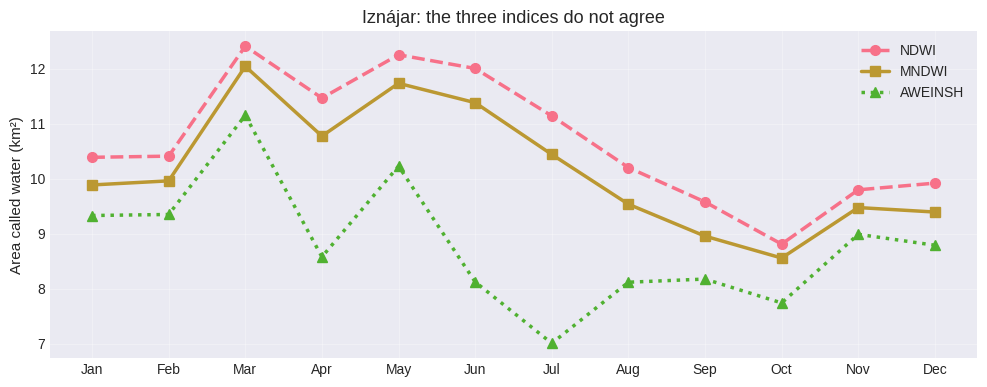

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, style in zip(area_by_index.columns, ['o--', 's-', '^:']):
    ax.plot(area_by_index.index, area_by_index[name], style, label=name.upper())
ax.set_ylabel('Area called water (km²)')
ax.set_title(f'{NAME}: the three indices do not agree')
ax.legend(frameon=False)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()

The three never agree, and the gap is not noise: in July, NDWI calls 11.1 km² water,
MNDWI 10.4 and AWEInsh 7.0. A third of the surface, depending on which formula you picked.

The order is consistent — NDWI > MNDWI > AWEInsh — and it says what each one is doing.
NDWI is the most generous because a dark, wet shore still looks like water in green
against NIR. AWEInsh is the strictest, built to be safe from shadow, and it pays for it by
losing the shallow edges. MNDWI sits between them, which is why it is the default choice
here and in most reservoir work.

The lesson is not "use MNDWI". It is that **"the surface of the reservoir" is not a
measurement until you say which index and which threshold produced it** — and that any
trend you compute afterwards inherits that choice.

## 4. How much water, month by month and year by year

The median across years smooths away the thing that matters most in a Mediterranean
reservoir: how different one year is from the next. `get_year_composite()` returns one
image per year, so the same masks give a surface for every month of every year — and
these are the years of the drought.

In [6]:
mndwi = water_indices['mndwi']
yearly = mndwi.get_year_composite()
years = list(range(YEARS[0], YEARS[1] + 1))

rows = []
images = yearly.toList(yearly.size())
for i, year in enumerate(years):
    image = ee.Image(images.get(i))
    areas = (image.gt(0).multiply(ee.Image.pixelArea()).divide(1e6)
             .reduceRegion(ee.Reducer.sum(), roi, 20, maxPixels=1e9).getInfo())
    for month in months:
        rows.append({'year': year, 'month': month, 'km2': areas.get(month)})

surface = pd.DataFrame(rows)
surface['month_num'] = surface['month'].map({m: i + 1 for i, m in enumerate(months)})
table = surface.pivot_table(index='year', columns='month_num', values='km2')
table.columns = [m[:3].capitalize() for m in months]
table.round(1)

Year 2020: 12/12 periods with data using mndwi index


Year 2021: 12/12 periods with data using mndwi index


No data for period 3 (march) in year 2022, filled with a masked band
No data for period 4 (april) in year 2022, filled with a masked band
Year 2022: 10/12 periods with data using mndwi index


Year 2023: 12/12 periods with data using mndwi index


No data for period 3 (march) in year 2024, filled with a masked band
No data for period 10 (october) in year 2024, filled with a masked band
Year 2024: 10/12 periods with data using mndwi index


Year 2025: 12/12 periods with data using mndwi index


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2020,13.7,13.8,14.6,14.2,15.1,14.0,12.9,11.2,10.5,10.1,10.2,7.4
2021,11.4,8.0,11.3,11.6,11.9,11.5,10.1,9.2,8.7,8.6,8.9,9.3
2022,9.8,9.4,0.0,0.0,9.8,9.8,8.9,8.0,7.2,6.8,0.2,7.9
2023,8.4,8.6,8.9,9.2,5.7,9.1,8.8,8.6,8.0,7.9,8.2,8.1
2024,8.5,9.4,0.0,9.7,11.6,11.3,10.8,9.9,9.3,0.0,9.3,9.7
2025,9.9,10.6,11.8,9.8,12.0,11.9,11.4,10.2,9.1,9.0,9.7,9.5


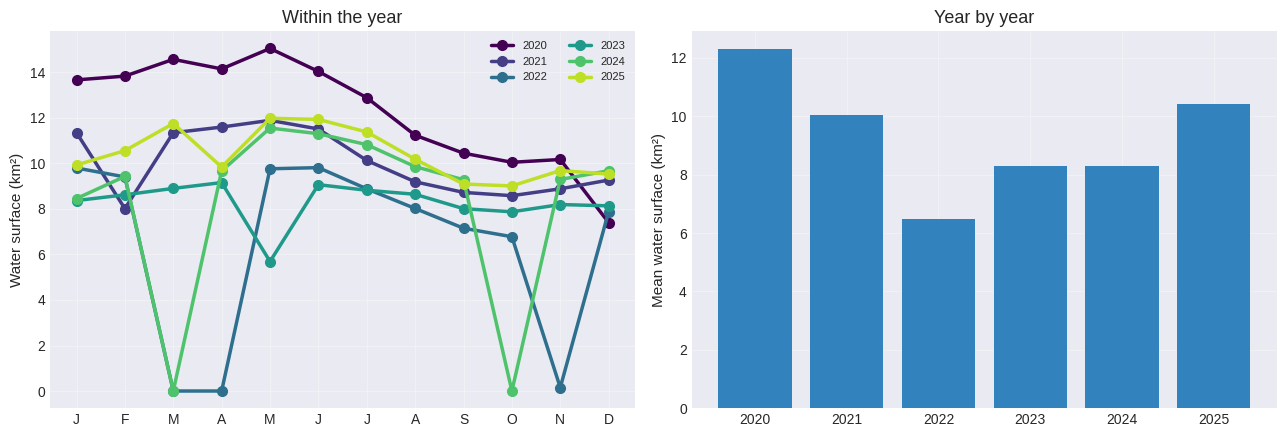

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colours = plt.cm.viridis(np.linspace(0, 0.9, len(years)))
for (year, group), colour in zip(surface.groupby('year'), colours):
    axes[0].plot(group['month_num'], group['km2'], 'o-', color=colour, label=str(year))
axes[0].set_xticks(range(1, 13), [m[:1].upper() for m in months])
axes[0].set_ylabel('Water surface (km²)')
axes[0].set_title('Within the year')
axes[0].legend(frameon=False, ncol=2, fontsize=8)

annual = surface.groupby('year')['km2'].mean()
axes[1].bar([str(y) for y in annual.index], annual.values, color='#3182bd')
axes[1].set_ylabel('Mean water surface (km²)')
axes[1].set_title('Year by year')

for ax in axes:
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
plt.tight_layout()

This is a drought, read off a satellite.

January 2020 starts at 13.7 km² and December of that year ends at 7.4 — the reservoir
loses nearly half its surface in one irrigation season. 2021 opens lower (11.4), 2022
lower still, and 2023 is the floor: it never gets above 9.2 km² all year. Then 2024 and
2025 recover, ending at 11.8 in March 2025.

The within-year shape is the same every time — fill with the winter rains, draw down from
May to October — but the *level* it starts from drops year after year until 2023.

**Read the zeros as missing data, not as an empty reservoir.** March and April 2022,
March and October 2024: those months had no Sentinel-2 scene that passed the cloud filter,
so the composite band is masked and the area sums to zero. The notebook prints a warning
for each when it builds them. A monthly series from optical imagery always needs that
check before anyone reads a collapse into it.

## 5. The permanent pool

For anything about water *quality*, the pixels have to be water in every month of the
series. A pixel that is shore in August and water in March carries a chlorophyll value
that means two different things at two times of year, and comparing them is meaningless.

The permanent pool is the intersection of the twelve monthly masks.

In [8]:
is_water = composites['mndwi'].gt(0)             # twelve binary bands
months_wet = is_water.reduce(ee.Reducer.sum())
permanent = months_wet.eq(12).selfMask()         # water in all twelve months

area = lambda img: (img.multiply(ee.Image.pixelArea()).divide(1e6)
                    .reduceRegion(ee.Reducer.sum(), roi, 20, maxPixels=1e9)
                    .values().get(0).getInfo())

print(f'reservoir outline:  {reservoir.area(10).divide(1e6).getInfo():.2f} km²')
print(f'permanent water:    {area(permanent.unmask(0)):.2f} km²')
print(f'water in March:     {area(is_water.select("march")):.2f} km²')
print(f'water in July:      {area(is_water.select("july")):.2f} km²')

reservoir outline:  24.41 km²


permanent water:    8.39 km²


water in March:     12.04 km²


water in July:      10.44 km²


Three numbers worth sitting with: the outline says 24.4 km², March holds 12.0, July holds
10.4, and only **8.4 km² is water every single month** of the six years.

The outline is the reservoir at capacity, a level it has not seen in this series. Anything
averaged over that polygon mixes water with dry shore, and mixes them in a proportion that
changes with the season — which is enough to manufacture a chlorophyll cycle that is really
a shoreline cycle.

## 6. Chlorophyll over the water

NDCI compares the red edge band (B5, 705 nm) with red: chlorophyll reflects the first and
absorbs the second, so the index rises with algal concentration. It needs the red edge, so
it is a Sentinel-2 index — Landsat cannot compute it.

Values above roughly 0.1 are read as a productive bloom in inland waters (Mishra & Mishra,
2012). The composites are built like the water ones and then masked to the permanent
pool.

In [9]:
chl = NdviSeasonality(roi=roi, sat='S2', index='ndci', key='median', periods=12,
                      start_year=YEARS[0], end_year=YEARS[1])

ndci_years = chl.get_year_composite()
ndci = ndci_years.median().updateMask(permanent)

monthly_ndci = ndci.reduceRegion(ee.Reducer.mean(), roi, 20, maxPixels=1e9).getInfo()
series = pd.Series({m: monthly_ndci[m] for m in months}, name='NDCI')
series.round(3).to_frame().T

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2020: 12/12 periods with data using ndci index


Year 2021: 12/12 periods with data using ndci index


No data for period 3 (march) in year 2022, filled with a masked band
No data for period 4 (april) in year 2022, filled with a masked band
Year 2022: 10/12 periods with data using ndci index


Year 2023: 12/12 periods with data using ndci index


No data for period 3 (march) in year 2024, filled with a masked band
No data for period 10 (october) in year 2024, filled with a masked band
Year 2024: 10/12 periods with data using ndci index


Year 2025: 12/12 periods with data using ndci index


,january,february,march,april,may,june,july,august,september,october,november,december
NDCI,-0.365,-0.19,-0.138,-0.111,-0.026,-0.007,-0.01,-0.022,-0.091,-0.084,-0.382,-0.251


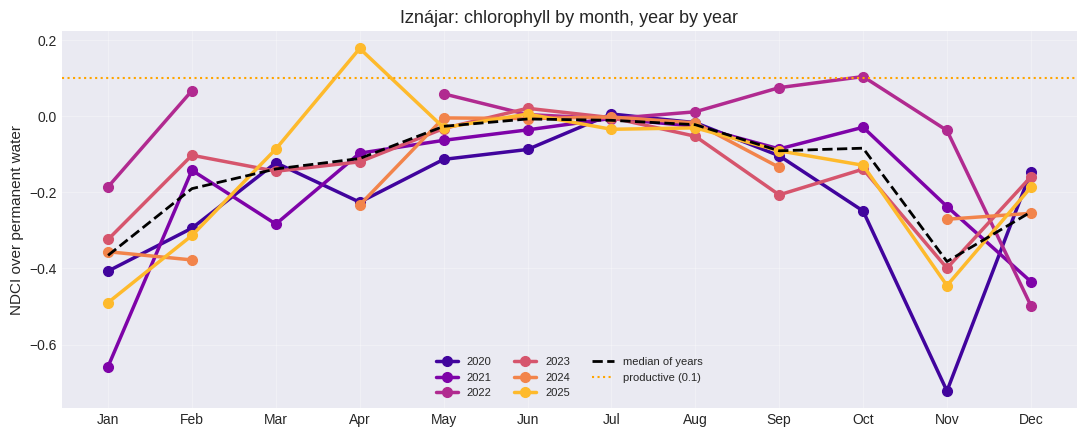

In [10]:
# The same, year by year: a median across years hides how variable this is.
# get_stats() is the library's zonal statistics: it runs reduceRegions over the
# image and returns a GeoDataFrame, one row per feature. Because the composite
# is already masked to the permanent water, the reducer ignores the land by
# itself — no need to turn the mask into a polygon
reservoir_fc = reservoirs.filter(ee.Filter.eq('Nombre', NAME))

rows = []
images = ndci_years.toList(ndci_years.size())
for i, year in enumerate(years):
    masked_year = ee.Image(images.get(i)).updateMask(permanent)
    stats = chl.get_stats(image=masked_year, geom=reservoir_fc, stat='MEAN', scale=20)
    values = stats.iloc[0]
    for month in months:
        rows.append({'year': year, 'month': month, 'ndci': values.get(month)})

ndci_by_year = pd.DataFrame(rows)
ndci_by_year['month_num'] = ndci_by_year['month'].map({m: i + 1 for i, m in enumerate(months)})

fig, ax = plt.subplots(figsize=(11, 4.5))
colours = plt.cm.plasma(np.linspace(0.1, 0.85, len(years)))
for (year, group), colour in zip(ndci_by_year.groupby('year'), colours):
    ax.plot(group['month_num'], group['ndci'], 'o-', color=colour, label=str(year))
ax.plot(range(1, 13), series.values, 'k--', lw=2, label='median of years')
ax.axhline(0.1, color='orange', ls=':', lw=1.5, label='productive (0.1)')
ax.set_xticks(range(1, 13), [m[:3].capitalize() for m in months])
ax.set_ylabel('NDCI over permanent water')
ax.set_title(f'{NAME}: chlorophyll by month, year by year')
ax.legend(frameon=False, ncol=3, fontsize=8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()

Every month is negative, from −0.38 in November to −0.01 in June. NDCI above ~0.1 is the
usual threshold for a productive bloom, so **Iznájar is not blooming**: this is a
comparatively clear, oligotrophic reservoir, and everything that follows is the timing of
a *relative* maximum. The method answers "when is this pixel at its highest" whether or not
the highest is high.

The shape is what a Mediterranean reservoir should do — minimum in late autumn when cold
turbid water comes in, plateau from May to August when the water is warm and stratified —
and the year-by-year lines show how much a median hides: the spread between years at the
same month is wider than the difference between spring and summer in any single year.

## 7. Is it trending?

`TimeSeriesAnalyzer` takes the same processor and extracts the series as a DataFrame,
then tests it for trend. Mann-Kendall is the right test here: it asks only whether values
tend to rise or fall over time, without assuming the trend is a straight line or that the
data are normal — both of which a seasonal water index violates.

In [11]:
analyzer = TimeSeriesAnalyzer(chl)

# extract_time_series() samples ONE point, and with no point given it takes
# the centroid of the ROI — which in a reservoir shaped like a flooded valley
# is dry land. It returns a perfectly good NDCI series of a hillside.
# The series that means something here is the monthly mean over the permanent
# water, which section 6 already computed, so it is handed over directly
series_over_water = ndci_by_year.dropna(subset=['ndci']).copy()
series_over_water['date'] = pd.to_datetime(
    dict(year=series_over_water['year'], month=series_over_water['month_num'], day=15))
series_over_water = (series_over_water
                     .rename(columns={'ndci': 'value', 'month': 'period'})
                     .sort_values('date')
                     .reset_index(drop=True))
series_over_water['doy'] = series_over_water['date'].dt.dayofyear
series_over_water['month'] = series_over_water['month_num']

print(series_over_water[['date', 'value', 'year', 'period']].head())

trend = analyzer.analyze_trend(df=series_over_water, method='all')
mk = trend['mann_kendall']
print(f"\nMann-Kendall over the permanent water: tau = {mk['tau']:.3f}, p = {mk['p_value']:.4f}")
print(trend.get('interpretation', ''))

        date     value  year    period
0 2020-01-15 -0.406848  2020   january
1 2020-02-15 -0.293943  2020  february
2 2020-03-15 -0.122021  2020     march
3 2020-04-15 -0.225715  2020     april
4 2020-05-15 -0.113160  2020       may

Mann-Kendall over the permanent water: tau = 0.043, p = 0.6076
No significant trend (p=0.608)


**tau = 0.043, p = 0.61: no trend.** Six years of monthly values, with no direction to
speak of — well inside what chance produces.

Mann-Kendall is the right test for this series: it asks only whether values tend to rise or
fall, without assuming a straight line or a normal distribution, both of which a seasonal
water index violates. What it cannot do is separate a trend from a cycle, which is why the
seasonal structure above has to be understood before a trend is even asked for.

And note what the series had to be. `extract_time_series()` with no point given falls back
to the centroid of the ROI — and the centroid of a reservoir shaped like a flooded valley
is a hillside. It would have returned a clean, plausible NDCI series of dry land, with
values around 0.30 against the −0.14 the water actually has. The series tested here is the
monthly mean over the permanent water instead.

## 8. The month of the peak, pixel by pixel

Everything so far is the reservoir averaged into one number per month. That hides the
question this notebook exists for: whether every part of the reservoir peaks at the same
time.

`get_peak_period()` answers it per pixel. The `composite=` argument is what makes it
usable here — the peak is taken from the composite **already masked to water**, instead
of being recomputed over land and water alike.

In [12]:
peak = chl.get_peak_period(composite=ndci, return_peak_value=True, return_ties=True)

counts = {m: peak.select('peak_period').eq(i + 1).selfMask()
             .reduceRegion(ee.Reducer.count(), roi, 20, maxPixels=1e9)
             .getInfo()['peak_period']
          for i, m in enumerate(months)}
pd.Series(counts, name='pixels peaking').to_frame().T

,january,february,march,april,may,june,july,august,september,october,november,december
pixels peaking,0,130,128,2486,1654,9203,8664,2297,219,1341,77,209


In [13]:
ties = peak.select('ties').reduceRegion(ee.Reducer.mean(), roi, 20,
                                        maxPixels=1e9).getInfo()['ties']
above = peak.select('peak_value').reduceRegion(ee.Reducer.mean(), roi, 20,
                                               maxPixels=1e9).getInfo()['peak_value']
print(f'mean number of months tied at the maximum: {ties:.3f}')
print(f'mean NDCI at the peak: {above:.3f}  (annual mean: {series.mean():.3f})')

mean number of months tied at the maximum: 1.000
mean NDCI at the peak: 0.029  (annual mean: -0.140)


**June and July hold the peak of nearly 70% of the water pixels**, with April and May
behind them. The average pixel peaks at NDCI 0.029 against an annual mean of −0.140, so the
maximum stands well clear of the rest of the year: this is a real seasonal signal, not a
coin flip between twelve similar months.

And **no ties at all** — a mean of exactly 1.000 months tied. NDCI is a continuous ratio, so
two months landing on precisely the same value would be a coincidence. On an integer count
they would be the norm.

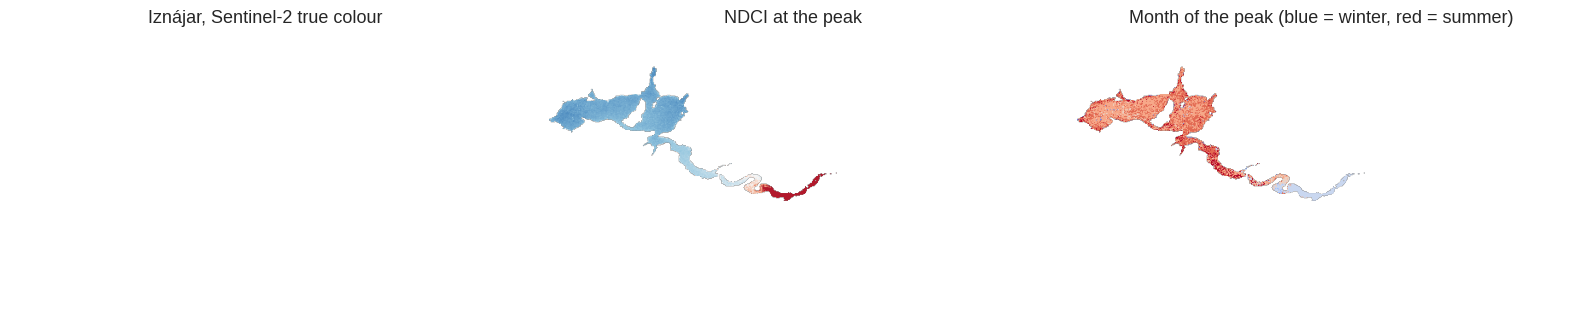

In [14]:
def thumbnail(image, vis, region, dimensions=600):
    url = image.visualize(**vis).getThumbURL(
        {'region': region, 'dimensions': dimensions, 'format': 'png'})
    return np.array(Image.open(BytesIO(urlopen(url).read())))

# True colour, for context: which reservoir is this and what is around it
s2_rgb = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(roi).filterDate(f'{YEARS[1]}-06-01', f'{YEARS[1]}-09-01')
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)).median())

month_vis = {'min': 1, 'max': 12,
             'palette': ['#3b4cc0', '#6788ee', '#9abbff', '#c9d7f0', '#edd1c2',
                         '#f7a889', '#e26952', '#b40426', '#e26952', '#f7a889',
                         '#c9d7f0', '#6788ee']}
ndci_vis = {'min': -0.1, 'max': 0.3,
            'palette': ['#2166ac', '#92c5de', '#f7f7f7', '#f4a582', '#b2182b']}

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
axes[0].imshow(thumbnail(s2_rgb, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.25},
                         roi))
axes[0].set_title(f'{NAME}, Sentinel-2 true colour')
axes[1].imshow(thumbnail(peak.select('peak_value'), ndci_vis, roi))
axes[1].set_title('NDCI at the peak')
axes[2].imshow(thumbnail(peak.select('peak_period'), month_vis, roi))
axes[2].set_title('Month of the peak (blue = winter, red = summer)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

The true-colour image on the left is there so the rest means something: this is Iznájar, a
reservoir filling a valley between olive-covered hills, with narrow arms where the rivers
come in and a wide body by the dam.

The middle map is how much chlorophyll the peak reaches; the right one is *when* it happens,
and it is the one that is not uniform. The arms and the shallow edges carry different timing
from the open water — which is the gradient the next section measures.

## 9. Open water and shallow arms

A reservoir fills a valley, so the obvious split is by elevation: the tail upstream, the
dam at the deepest point. It does not work, and the reason is worth keeping.

SRTM flew in **February 2000**, and Iznájar was closed in **1969**. Radar does not see
through water, so what the DEM holds over this reservoir is the surface of the
reservoir — a flat 396 m, identical at the 25th and the 75th percentile. The drowned
valley is not in there. (It would be for a reservoir built *after* the DEM was made,
which is the sort of accident that makes a method work in one place and fail silently in
another.)

What does work is the geometry of the water itself. The arms where the rivers come in are
narrow, so every pixel in them is close to a shore; the main body is wide, so its centre
is far from any. Distance to the shoreline is a usable proxy for the limnological
gradient, and it comes from the water mask with no extra data.

In [15]:
SCALE, CRS = 20, 'EPSG:25830'

water01 = permanent.unmask(0).reproject(crs=CRS, scale=SCALE)

# fastDistanceTransform measures the distance to the nearest NON-ZERO pixel,
# so it has to run on the land mask: run on the water it returns zero
# everywhere inside the water, which is exactly where we need the distance
to_shore = (water01.Not().fastDistanceTransform(256).sqrt().multiply(SCALE)
            .updateMask(permanent).rename('to_shore'))

cuts = to_shore.reduceRegion(ee.Reducer.percentile([25, 75]), roi, SCALE,
                             maxPixels=1e9).getInfo()
near, far = cuts['to_shore_p25'], cuts['to_shore_p75']
print(f'distance to the shore: {near:.0f} m (p25) to {far:.0f} m (p75)')

zones = {'shallow arms (nearest quarter to a shore)': to_shore.lte(near),
         'open water (farthest quarter from any shore)': to_shore.gte(far)}

rows = []
for label, mask in zones.items():
    zone = peak.updateMask(mask)
    share = {m: zone.select('peak_period').eq(i + 1).selfMask()
                .reduceRegion(ee.Reducer.count(), roi, SCALE, maxPixels=1e9)
                .getInfo()['peak_period']
             for i, m in enumerate(months)}
    total = sum(share.values()) or 1
    rows.append(pd.Series({m: v / total for m, v in share.items()}, name=label))

zone_table = pd.DataFrame(rows)
zone_table.style.format('{:.0%}').background_gradient(cmap='Greens', axis=1)

distance to the shore: 57 m (p25) to 234 m (p75)


,january,february,march,april,may,june,july,august,september,october,november,december
shallow arms (nearest quarter to a shore),0%,2%,1%,21%,7%,15%,23%,13%,3%,14%,1%,1%
open water (farthest quarter from any shore),0%,0%,0%,0%,5%,53%,38%,1%,0%,1%,0%,1%


In [16]:
weights = np.arange(1, 13)
for label, row in zone_table.iterrows():
    print(f'{label:48s} mean peak month = {float((row.values * weights).sum()):.2f}')

shallow arms (nearest quarter to a shore)        mean peak month = 6.67
open water (farthest quarter from any shore)     mean peak month = 6.48


The prediction going in was that the shallow arms would peak **earlier**: shallower, fed
directly by the rivers, quicker to warm. They do not. The mean peak month is 6.67 in the
arms against 6.48 in the open water — if anything a fortnight later, well inside the noise.
That hypothesis is not supported here.

What the table shows instead is a difference of another kind: **not when, but how tightly.**

The open water is emphatic. Ninety-one per cent of its pixels peak in June or July (53% and
38%) and almost none outside them: a deep, well-mixed body follows the thermal cycle and
nothing else, so all of it does the same thing at the same time.

The shallow arms are scattered — 23% in July, 21% in April, 15% in June, 14% in October.
They answer to what their own river brings, and those events do not share a calendar. The
arms are not early, they are **individually driven**.

That is more useful than the expected result, because it says where an average misleads: a
reservoir-wide monthly mean describes the open water fairly and the arms badly, and the arms
are exactly where a bloom tends to start.

## 10. The same question across reservoirs

One reservoir is an anecdote. The same three calls over the largest reservoirs of the
basin say whether the timing is a property of this valley or of the region's climate.

In [17]:
def peak_month_of(name, years=YEARS):
    """Modal month of the chlorophyll peak over a reservoir's permanent water."""
    geom = reservoirs.filter(ee.Filter.eq('Nombre', name)).first().geometry()
    area_ = geom.buffer(300)

    w = NdviSeasonality(roi=area_, sat='S2', index='mndwi', key='median', periods=12,
                        start_year=years[0], end_year=years[1])
    pool = w.get_year_composite().median().gt(0).reduce(ee.Reducer.sum()).eq(12).selfMask()

    c = NdviSeasonality(roi=area_, sat='S2', index='ndci', key='median', periods=12,
                        start_year=years[0], end_year=years[1])
    masked = c.get_year_composite().median().updateMask(pool)
    p = c.get_peak_period(composite=masked)

    counts_ = {m: p.eq(i + 1).selfMask()
                  .reduceRegion(ee.Reducer.count(), area_, 20, maxPixels=1e9)
                  .getInfo()['peak_period']
               for i, m in enumerate(c.period_names)}
    total = sum(counts_.values()) or 1
    best = max(counts_, key=counts_.get)
    return {'reservoir': name, 'peak month': best,
            'share of pixels': counts_[best] / total, 'water pixels': total}

names = ['Iznájar', 'Puente Nuevo', 'Encinarejo', 'Melonares', 'Guadalén']
pd.DataFrame([peak_month_of(n) for n in names]).set_index('reservoir')

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2020: 12/12 periods with data using mndwi index


Year 2021: 12/12 periods with data using mndwi index


No data for period 3 (march) in year 2022, filled with a masked band
No data for period 4 (april) in year 2022, filled with a masked band
Year 2022: 10/12 periods with data using mndwi index


Year 2023: 12/12 periods with data using mndwi index


...

No data for period 11 (november) in year 2022, filled with a masked band
Year 2022: 11/12 periods with data using ndci index


Year 2023: 12/12 periods with data using ndci index


No data for period 3 (march) in year 2024, filled with a masked band
Year 2024: 11/12 periods with data using ndci index


Year 2025: 12/12 periods with data using ndci index


,peak month,share of pixels,water pixels
reservoir,,,
Iznájar,june,0.348493,26408
Puente Nuevo,august,0.534627,20620
Encinarejo,august,0.813972,7558
Melonares,april,0.288396,31533
Guadalén,may,0.292103,11181


Five reservoirs in one basin, under one climate, peaking in **four different months**:
Iznájar in June, Melonares in April, Guadalén in May, Puente Nuevo and Encinarejo in August.
If regional weather set the timing they would move together. They do not, so what sets it is
local — depth, residence time, the catchment upstream, and how the dam is operated.

The concentration varies as much as the month. Encinarejo gives August **81%** of its
pixels — a small reservoir behaving as a single body — while Iznájar spreads June over 35%,
which is what a large reservoir with distinct arms looks like. That share is as informative
as the month itself: it says whether "the reservoir peaks in August" is a description or an
average of several different things.

## 11. Taking the maps out

Everything here is an `ee.Image`, so it exports like any other. `peak_period` is a single
band of month numbers and weighs almost nothing; the water masks are what a GIS usually
wants.

In [18]:
exports = {
    f'{NAME}_chlorophyll_peak': peak.select(['peak_period', 'peak_value']).toFloat(),
    f'{NAME}_permanent_water': permanent.unmask(0).toByte(),
    f'{NAME}_monthly_water': is_water.toByte(),
}

for description, image in exports.items():
    task = ee.batch.Export.image.toDrive(
        image=image, description=description, folder='ndvi2gif',
        region=roi, scale=20, crs=CRS, maxPixels=1e9)
    # task.start()      # uncomment to launch them
    print(f'{description}: {image.bandNames().size().getInfo()} band(s)')

print('\nband 1 of the peak export =', dict(enumerate(months, start=1)))

Iznájar_chlorophyll_peak: 2 band(s)


Iznájar_permanent_water: 1 band(s)


Iznájar_monthly_water: 12 band(s)

band 1 of the peak export = {1: 'january', 2: 'february', 3: 'march', 4: 'april', 5: 'may', 6: 'june', 7: 'july', 8: 'august', 9: 'september', 10: 'october', 11: 'november', 12: 'december'}


## 12. What to take away

**"The surface of the reservoir" is not a measurement until you name the index.** NDWI,
MNDWI and AWEInsh disagree by a third of the surface in the same month, in a consistent
order that follows what each formula forgives.

**Build the mask from the data, not from the outline.** Iznájar's polygon is 24.4 km²; the
water that is there every month is 8.4. Averaging an index over the polygon mixes water and
shore in a proportion that changes with the season, which invents a cycle on its own.

**Check the gaps before reading a collapse.** The zeros in the surface table are months
without a usable Sentinel-2 scene, not an empty reservoir. The drought in the series is
real — half the surface lost between 2020 and 2023 — but it has to be read past the holes.

**A peak is not a bloom.** Every monthly NDCI here is negative. `get_peak_period()` answers
*when* just as confidently on a clear reservoir as on a eutrophic one, so the timing map
belongs next to the values, which is what `return_peak_value=True` is for.

**The inside of a reservoir is not uniform — but not in the way expected.** The shallow arms
do not peak earlier than the open water; they peak *less predictably*, spread over four
months where the open body concentrates 91% of itself into two.

**Check that your proxy measures what you think.** Two silent failures in this notebook, both
caught only by looking at intermediate numbers: the elevation split returned identical
quartiles, because SRTM flew in 2000 and the reservoir closed in 1969, so the DEM holds the
water surface and not the valley floor; and the default time series sampled the ROI centroid,
which in this shape is a hillside.

**Timing is local.** Five reservoirs under one climate peak in four different months.